# Fetal USG Ellipse Detection Pipeline with Manual ROI Selection

Notebook ini menambahkan input ROI manual menggunakan OpenCV.

Pipeline:

1. Load citra USG
2. User memilih ROI kepala janin
3. Crop ROI
4. Preprocessing
5. Canny Edge Detection
6. Randomized Ellipse Search (IRHT approximation)
7. Visualisasi ellipse
8. Estimasi BPD

Catatan:
- ROI manual digunakan untuk membatasi area pencarian.
- Implementasi IRHT di sini adalah pendekatan edukasi menggunakan random sampling + ellipse fitting.


## 1. Import Library

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random


## 2. Load Citra USG

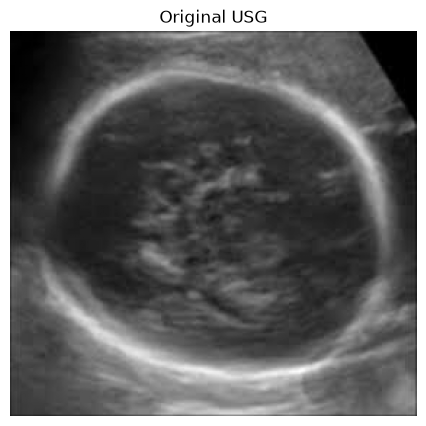

In [13]:
image_path = "../img/janin/images.jpg"

img = cv2.imread(image_path)

if img is None:
    raise FileNotFoundError(
        "File image tidak ditemukan"
    )

gray = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2GRAY
)

plt.figure(figsize=(7,5))
plt.imshow(gray, cmap="gray")
plt.title("Original USG")
plt.axis("off");


## 3. Manual ROI Selection

User memilih area kepala janin.

Drag kotak ROI kemudian tekan ENTER.


In [14]:
roi = cv2.selectROI(
    "Select Fetal Head ROI",
    img,
    showCrosshair=True,
    fromCenter=False
)

cv2.destroyAllWindows()

x,y,w,h = roi

print(
    "ROI coordinate:",
    x,y,w,h
)


ROI coordinate: 7 22 263 224


## 4. Crop ROI

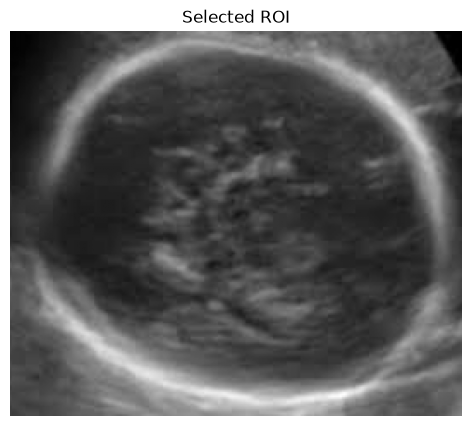

In [15]:
roi_img = img[
    y:y+h,
    x:x+w
]

roi_gray = cv2.cvtColor(
    roi_img,
    cv2.COLOR_BGR2GRAY
)

plt.figure(figsize=(6,5))
plt.imshow(roi_gray, cmap="gray")
plt.title("Selected ROI")
plt.axis("off");


## 5. Preprocessing

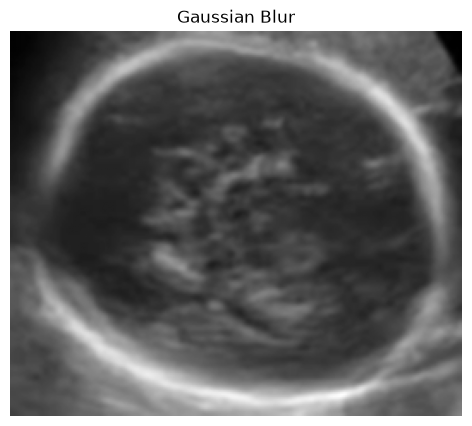

In [16]:
blur = cv2.GaussianBlur(
    roi_gray,
    (5,5),
    0
)

plt.figure(figsize=(6,5))
plt.imshow(blur, cmap="gray")
plt.title("Gaussian Blur")
plt.axis("off");


## 6. Canny Edge Detection

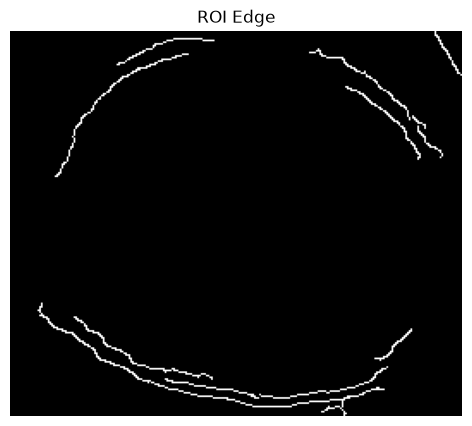

In [17]:
edges = cv2.Canny(
    blur,
    50,
    150
)

plt.figure(figsize=(6,5))
plt.imshow(edges, cmap="gray")
plt.title("ROI Edge")
plt.axis("off");


## 7. Extract Edge Points

Jumlah edge point: 1025


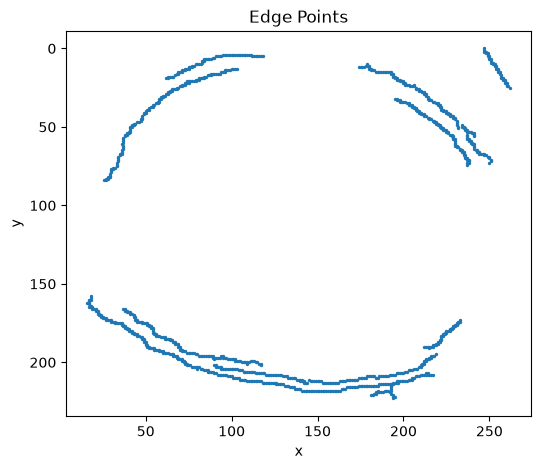

In [18]:
points = np.column_stack(
    np.where(edges > 0)
)

print(
    "Jumlah edge point:",
    len(points)
)

plt.figure(figsize=(6,5))
plt.scatter(
    points[:,1],
    points[:,0],
    s=2
)

plt.gca().invert_yaxis()
plt.title("Edge Points")
plt.xlabel("x")
plt.ylabel("y");


## 8. Candidate Ellipse Generator

Menghasilkan kandidat ellipse dari sampling titik edge.


In [19]:
def generate_candidate(points):

    if len(points) < 5:
        return None

    sample = points[
        np.random.choice(
            len(points),
            5,
            replace=False
        )
    ]

    sample = sample[:,::-1].astype(
        np.int32
    )

    try:
        ellipse = cv2.fitEllipse(sample)
        return ellipse

    except:
        return None


## 9. Ellipse Scoring

Score berdasarkan overlap ellipse dengan edge image.


In [20]:
def ellipse_score(
    ellipse,
    edge_img
):

    canvas = np.zeros_like(edge_img)

    cv2.ellipse(
        canvas,
        ellipse,
        255,
        1
    )

    overlap = np.logical_and(
        canvas > 0,
        edge_img > 0
    )

    return np.sum(overlap)


## 10. Iterative Random Search (IRHT Approximation)


In [21]:
iterations = 500

best_score = 0
best_ellipse = None


for i in range(iterations):

    candidate = generate_candidate(points)

    if candidate is not None:

        score = ellipse_score(
            candidate,
            edges
        )

        if score > best_score:
            best_score = score
            best_ellipse = candidate


print("Best score:", best_score)
print("Ellipse:", best_ellipse)


Best score: 109
Ellipse: ((138.1396026611328, 110.15311431884766), (210.17274475097656, 232.26499938964844), 94.9655532836914)


## 11. Visualisasi Hasil

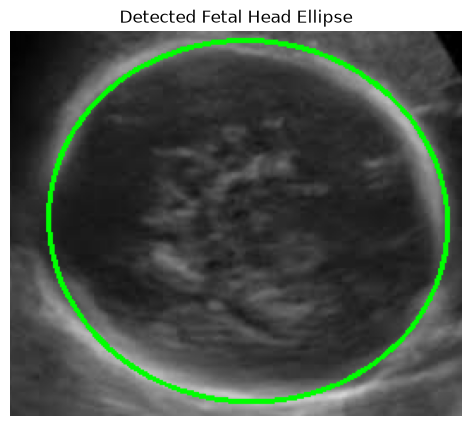

In [22]:
result = roi_img.copy()

if best_ellipse is not None:

    cv2.ellipse(
        result,
        best_ellipse,
        (0,255,0),
        2
    )


plt.figure(figsize=(6,5))
plt.imshow(
    cv2.cvtColor(
        result,
        cv2.COLOR_BGR2RGB
    )
)

plt.title("Detected Fetal Head Ellipse")
plt.axis("off");


## 12. Ambil Parameter Ellipse dan BPD

Output:

- Center
- Major axis
- Minor axis
- Rotation

BPD pendekatan:

BPD ≈ minor axis

Konversi pixel ke mm membutuhkan informasi skala USG.


In [23]:
if best_ellipse:

    center, axes, angle = best_ellipse

    print("Center:", center)
    print("Axes:", axes)
    print("Angle:", angle)

    BPD_pixel = axes[1]

    print(
        "BPD pixel:",
        BPD_pixel
    )
else:
    print("Ellipse tidak ditemukan")


Center: (138.1396026611328, 110.15311431884766)
Axes: (210.17274475097656, 232.26499938964844)
Angle: 94.9655532836914
BPD pixel: 232.26499938964844
